# Titanic Survival Prediction

### Objective
The objective of this project is to analyze the Titanic dataset, understand the data, perform data preprocessing, train machine learning models, and predict whether a passenger survived or not.

### Dataset
The dataset contains passenger information such as:

- Passenger Class
- Name
- Sex
- Age
- Number of Siblings/Spouses
- Number of Parents/Children
- Ticket Number
- Fare
- Cabin
- Embarked Port

**Target Variable:**
- Survived
  - 0 = Did Not Survive
  - 1 = Survived

# 1. Import Libraries

In [137]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

Load the Titanic dataset into a Pandas DataFrame.

In [138]:
df = pd.read_csv("../data/train.csv")

# 3. Data Overview

The `head()` function displays the first five rows of the dataset. This helps us understand the structure of the data and available features.

In [139]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Check Dataset Shape

The `shape` attribute returns the number of rows and columns present in the dataset.

In [140]:
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (891, 12)
Rows: 891
Columns: 12


## Display Column Names

Display all feature names available in the dataset.

In [141]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [142]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## Dataset Information

The `info()` function provides information about:

- Total rows
- Data types
- Non-null values
- Memory usage

It helps identify missing values and understand the structure of the dataset.

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# 4. Exploratory Data Analysis (EDA)

## Statistical Summary

The `describe()` function provides statistical information for numerical features.

It includes:

- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- 25th Percentile
- Median
- 75th Percentile

In [144]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [145]:
df['Survived'].mean()

np.float64(0.3838383838383838)

In [146]:
df['Fare'].max()

np.float64(512.3292)

In [147]:
df['Fare'].median()

np.float64(14.4542)

In [148]:
# Text Columns Summary
df.describe(include="object")

C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\2062798831.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [149]:
df['Sex'].describe()

count      891
unique       2
top       male
freq       577
Name: Sex, dtype: object

## Check Missing Values

Identify missing values present in each column of the dataset.

In [150]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [151]:
df.isnull().sum() / len(df) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [152]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Age         177
Cabin       687
Embarked      2
dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\2090161664.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values,y=missing.index,palette="Reds_r")


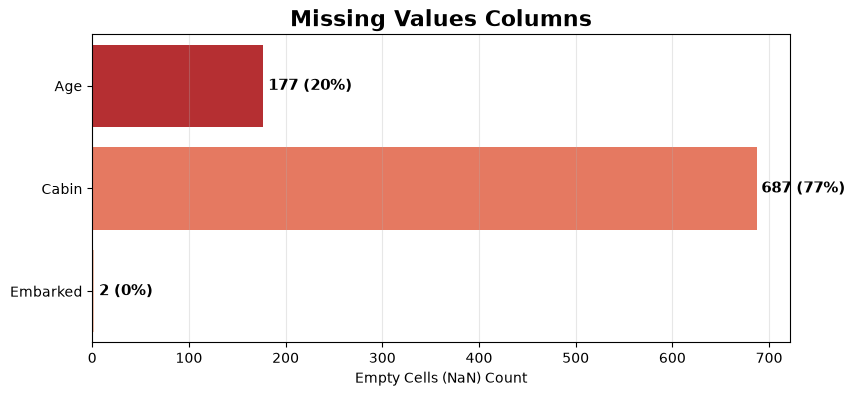

In [153]:
# Missing percentage
missing_percent = (missing / len(df) * 100).round(0)

# Plot
plt.figure(figsize=(9,4))
sns.barplot(x=missing.values,y=missing.index,palette="Reds_r")

# Labels
for i, (value, percent) in enumerate(zip(missing.values, missing_percent)):
    plt.text(value + 5,i,f"{value} ({int(percent)}%)",va="center",fontsize=11,fontweight="bold")

plt.title("Missing Values Columns", fontsize=16, fontweight="bold")
plt.xlabel("Empty Cells (NaN) Count")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)

plt.show()

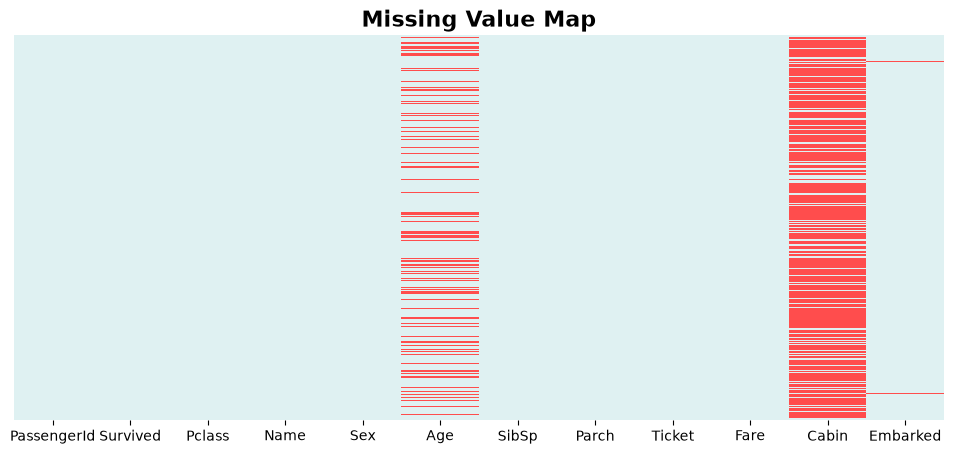

In [154]:
plt.figure(figsize=(12,5))

sns.heatmap(df.isnull(),cbar=False,cmap=["#dff1f2", "#ff4d4d"],yticklabels=False)

plt.title("Missing Value Map", fontsize=16, fontweight="bold")

plt.show()

## Check Duplicate Records

Check whether the dataset contains duplicate rows.

In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
# Remove duplicates
# df.drop_duplicates(inplace=True)

## Identify Numerical and Categorical Features

Separate numerical and categorical columns for further analysis.

In [157]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Numerical Features:")
print(numerical_columns)

print()

print("Categorical Features:")
print(categorical_columns)

Numerical Features:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

Categorical Features:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')


# Univariate Analysis

Univariate Analysis is used to understand the distribution of individual features in the dataset.

### Categorical Column

In [158]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [159]:
df["Sex"].value_counts(normalize=True) * 100

Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

### Categorical Features Analysis

In this section, we explore the distribution of categorical features in the Titanic dataset.

The following variables are analyzed:

- **Sex** – Distribution of male and female passengers.
- **Pclass** – Distribution of passengers across ticket classes.
- **Embarked** – Distribution of passengers based on their port of embarkation.

This analysis helps us understand the composition of the dataset and identify any class imbalance before building machine learning models.

C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\4044693030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Sex", palette="Set1")
C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\4044693030.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Male", "Female"])
C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\4044693030.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Pclass", palette="viridis")
C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\4044693030.py:17: UserWarning: set_ticklabels() should only be us

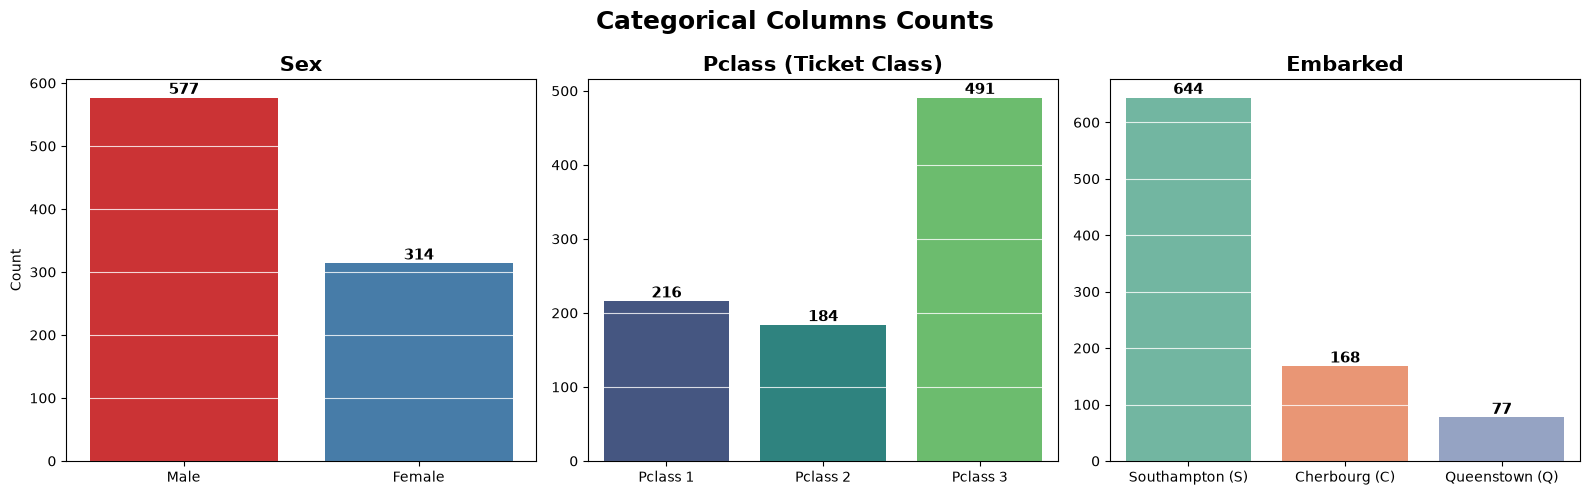

In [160]:
plt.figure(figsize=(16,5))

# Sex
plt.subplot(1,3,1)
ax = sns.countplot(data=df, x="Sex", palette="Set1")
ax.set_xticklabels(["Male", "Female"])
plt.title("Sex", fontsize=15, weight="bold")
plt.xlabel("")
plt.ylabel("Count")
for i in ax.containers:
    ax.bar_label(i, fontsize=11, weight="bold")
plt.grid(axis="y", alpha=0.8, color = 'White')

# Pclass
plt.subplot(1,3,2)
ax = sns.countplot(data=df, x="Pclass", palette="viridis")
ax.set_xticklabels(["Pclass 1", "Pclass 2", "Pclass 3"])
plt.title("Pclass (Ticket Class)", fontsize=15, weight="bold")
plt.xlabel("")
plt.ylabel("")
for i in ax.containers:
    ax.bar_label(i, fontsize=11, weight="bold")
plt.grid(axis="y", alpha=0.8, color = 'White')

# Embarked
plt.subplot(1,3,3)
ax = sns.countplot(data=df, x="Embarked", palette="Set2")
ax.set_xticklabels(["Southampton (S)","Cherbourg (C)","Queenstown (Q)"])
plt.title("Embarked", fontsize=15, weight="bold")
plt.xlabel("")
plt.ylabel("")

for i in ax.containers:
    ax.bar_label(i, fontsize=11, weight="bold")

plt.grid(axis="y", alpha=0.8, color = 'White')
plt.suptitle("Categorical Columns Counts",fontsize=18, weight="bold")
plt.tight_layout()
plt.show()

### Observation

- The dataset contains **577 male** passengers and **314 female** passengers, indicating that male passengers are the majority.
- Most passengers traveled in **Third Class (491)**, followed by **First Class (216)** and **Second Class (184)**.
- The majority of passengers embarked from **Southampton (644)**, while fewer passengers boarded at **Cherbourg (168)** and **Queenstown (77)**.
- These distributions provide valuable insights into the dataset and may influence survival prediction in the machine learning model.

## Target Variable: Survived

Let's analyze how many passengers survived and how many did not survive.

In [161]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

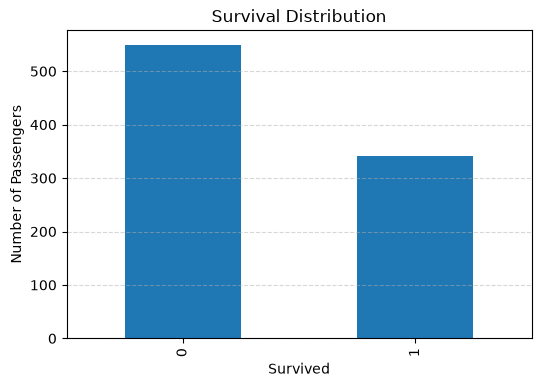

In [162]:
df["Survived"].value_counts().plot(kind="bar",figsize=(6,4))

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Interpretation

- Class **0** represents passengers who did not survive.
- Class **1** represents passengers who survived.
- The dataset contains more passengers who did not survive than those who survived.

## Passenger Class (Pclass)

Passenger class indicates the travel class of each passenger.

- 1 = First Class
- 2 = Second Class
- 3 = Third Class

In [163]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

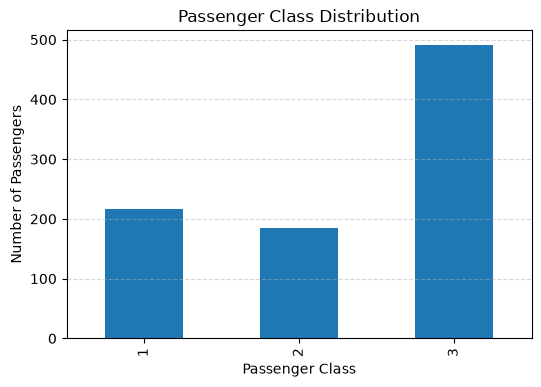

In [164]:
df["Pclass"].value_counts().sort_index().plot(kind="bar",figsize=(6,4))

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Interpretation

- Most passengers belonged to Third Class.
- First Class had the fewest passengers.

## Gender Distribution

Let's see how many male and female passengers are present in the dataset.

In [165]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

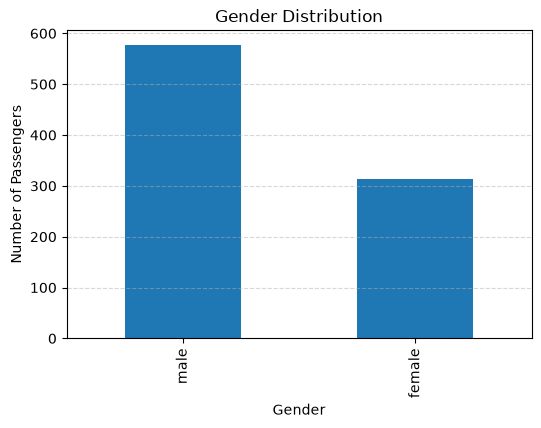

In [166]:
df["Sex"].value_counts().plot(kind="bar",figsize=(6,4))

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Interpretation

- The dataset contains more male passengers than female passengers.

## Age Distribution

Age is a numerical feature.

A histogram helps visualize how passenger ages are distributed.

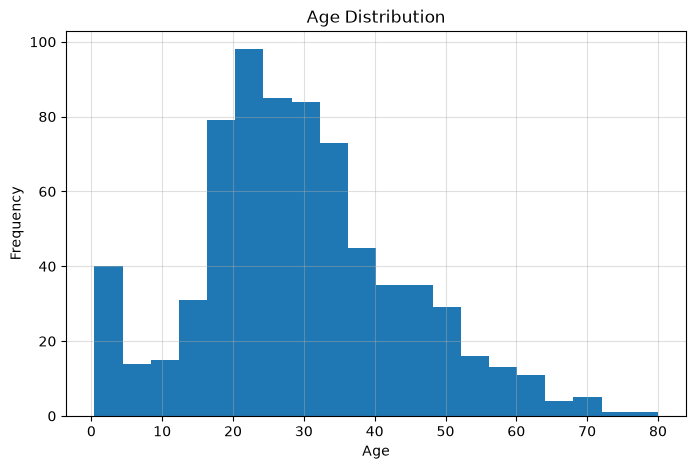

In [167]:
df["Age"].plot(kind="hist",bins=20,figsize=(8,5))

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(alpha=0.4)

plt.show()

### Interpretation

- Most passengers were between 20 and 40 years old.
- A few passengers were children.
- Some age values are missing.

## Fare Distribution

Fare represents the ticket price paid by each passenger.

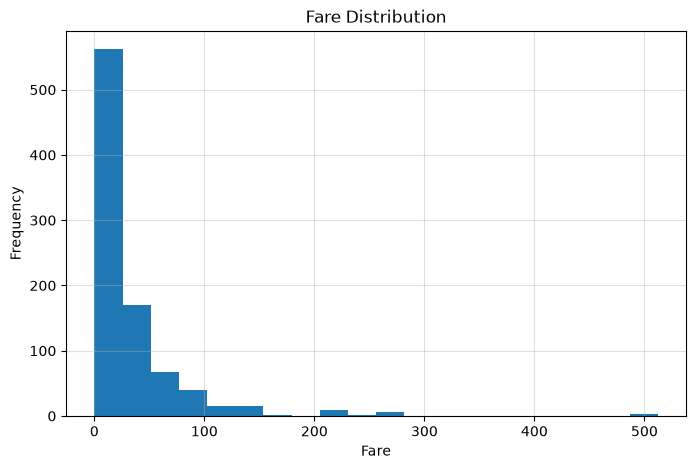

In [168]:
df["Fare"].plot(kind="hist",bins=20,figsize=(8,5))

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.grid(alpha=0.4)

plt.show()

### Interpretation

- Most passengers paid lower ticket fares.
- A few passengers paid very high fares.
- The distribution is positively skewed.

## Embarked Distribution

Embarked indicates the port from which passengers boarded the Titanic.

- C = Cherbourg
- Q = Queenstown
- S = Southampton

In [169]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [170]:
df["Embarked"].value_counts(normalize=True)*100

Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64

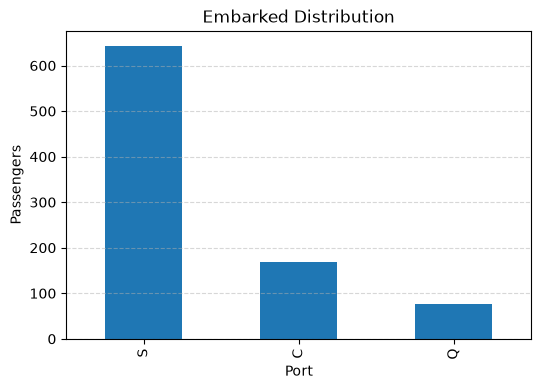

In [171]:
df["Embarked"].value_counts().plot(kind="bar",figsize=(6,4))

plt.title("Embarked Distribution")
plt.xlabel("Port")
plt.ylabel("Passengers")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observations

- Most passengers did not survive.
- Most passengers traveled in Third Class.
- Male passengers were more than female passengers.
- Most passengers were between 20 and 40 years old.
- Fare distribution is positively skewed.
- Southampton was the most common boarding port.

These observations provide a better understanding of the dataset before moving to feature relationships.

### Value Count SibSp

In [172]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

## Box Plot Analysis

A **Box Plot** is used to visualize the distribution of numerical data and identify **outliers**.

It provides information about:
- Median (middle value)
- Interquartile Range (IQR)
- Minimum and Maximum values
- Potential outliers

In this analysis, we use a box plot to examine the **Age** feature and check whether any unusual age values are present.

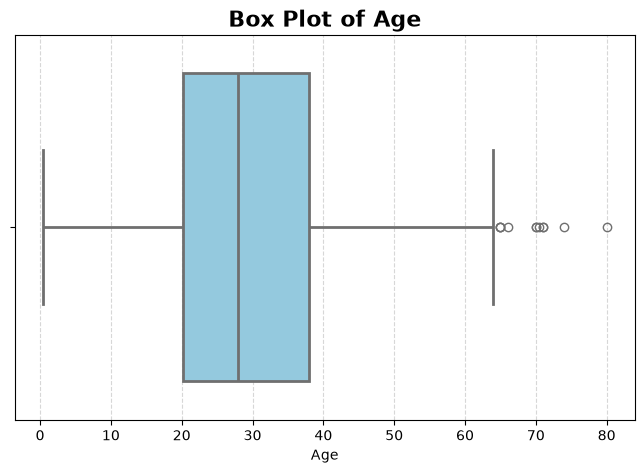

In [173]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Age"],color="skyblue",linewidth=2)

plt.title("Box Plot of Age", fontsize=16, fontweight="bold")
plt.xlabel("Age")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

### Observation

- The median age of passengers is approximately **28 years**.
- Most passengers are between **22 and 35 years** old (Interquartile Range).
- The age distribution is slightly **right-skewed**, with a few older passengers.
- Several passengers above **55 years** are identified as potential outliers.
- A few very young passengers (around 0–2 years) also appear near the lower end of the distribution.
- These outliers represent **real passenger ages**, so they should **not be removed** from the dataset.

# Bivariate Analysis

Bivariate Analysis is used to study the relationship between two variables.

Analyze how different features affect passenger survival.

In [174]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## Survival vs Passenger Class

Let's analyze whether passenger class affected the survival rate.

In [175]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [176]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


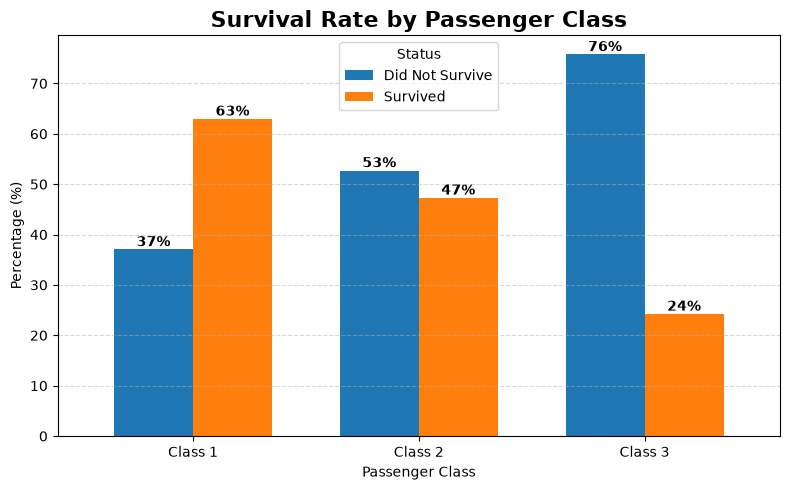

In [177]:
survival_rate = ( pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100)

# Rename columns
survival_rate.columns = ["Did Not Survive", "Survived"]

# Rename index
survival_rate.index = ["Class 1", "Class 2", "Class 3"]

# Plot
ax = survival_rate.plot(kind="bar",figsize=(8,5),width=0.7)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", fontsize=10, fontweight="bold")

plt.title("Survival Rate by Passenger Class", fontsize=16, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

- First Class passengers had a higher survival rate.
- Third Class passengers experienced the highest number of deaths.
- Passenger class appears to be an important feature for prediction.

## Survival vs Gender

Let's compare the survival rate of male and female passengers.

In [178]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


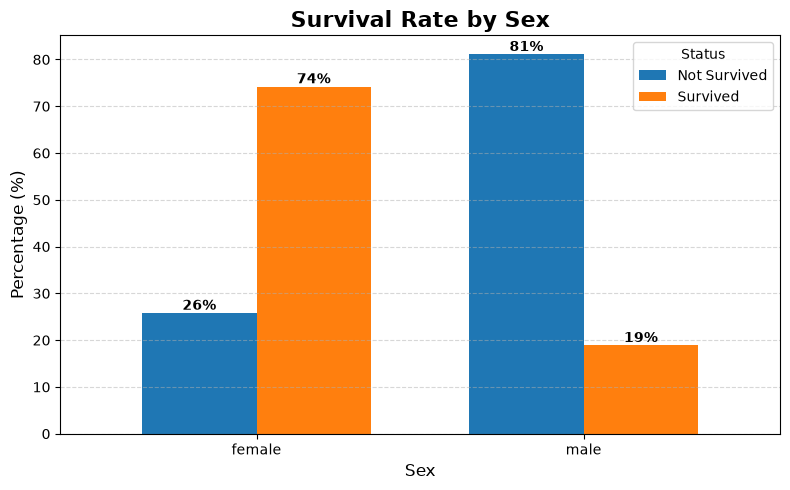

In [179]:
survival_rate = ( pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100)

# Rename columns
survival_rate.columns = ["Not Survived", "Survived"]

# Plot
ax = survival_rate.plot(kind="bar",figsize=(8,5),width=0.7)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", fontsize=10, fontweight="bold")

plt.title("Survival Rate by Sex", fontsize=16, fontweight="bold")
plt.xlabel("Sex", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

- Female passengers had a much higher survival rate.
- Most male passengers did not survive.
- Gender is one of the strongest predictors of survival.

## Age Distribution by Survival

This histogram compares the age distribution of passengers based on their survival status.

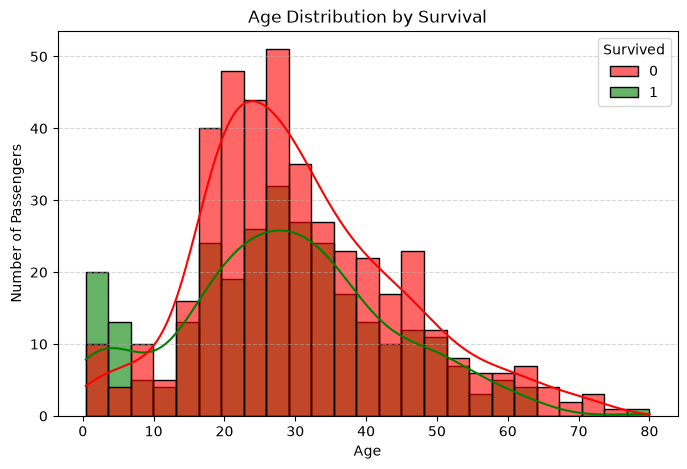

In [180]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,x="Age",hue="Survived",bins=25,kde=True,palette=["red", "green"],alpha=0.6)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

- Younger passengers had a relatively higher survival rate.
- Most passengers were between 20 and 40 years old.
- Survival decreased among older passengers.
- Age appears to have some influence on survival but is not the strongest predictor.

## Survival vs Embarked

Let's analyze survival based on the port of embarkation.

In [181]:
pd.crosstab(df["Embarked"], df["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


In [182]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

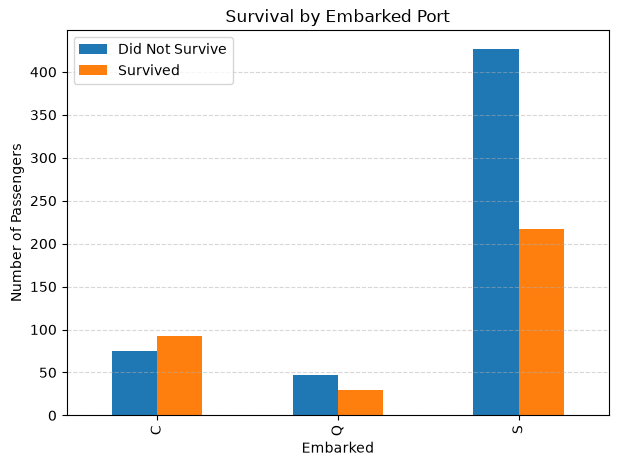

In [183]:
pd.crosstab(df["Embarked"], df["Survived"]).plot(kind="bar",figsize=(7,5))

plt.title("Survival by Embarked Port")
plt.xlabel("Embarked")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive","Survived"])
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Interpretation

- Survival rates differ among embarkation ports.
- Southampton (S) has the largest number of passengers.
- Embarked may have some influence on survival.

## Fare Distribution by Passenger Class

This box plot compares ticket fares across different passenger classes.

In [184]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\777499795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Pclass",y="Fare",palette="Set2")


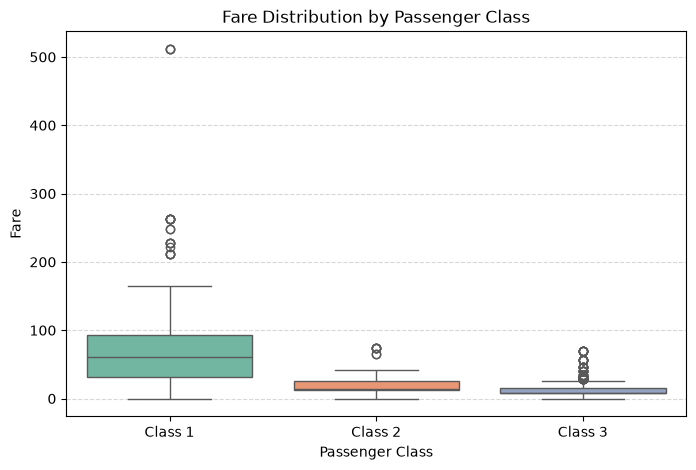

In [185]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="Pclass",y="Fare",palette="Set2")

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.xticks([0,1,2],["Class 1","Class 2","Class 3"])

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

- Class 1 passengers paid the highest fares.
- Class 2 passengers had moderate ticket prices.
- Class 3 passengers paid the lowest fares.
- The Fare feature is strongly related to passenger class.

## Relationship between Age and Fare

This scatter plot shows the relationship between passenger age and ticket fare while distinguishing survival status.

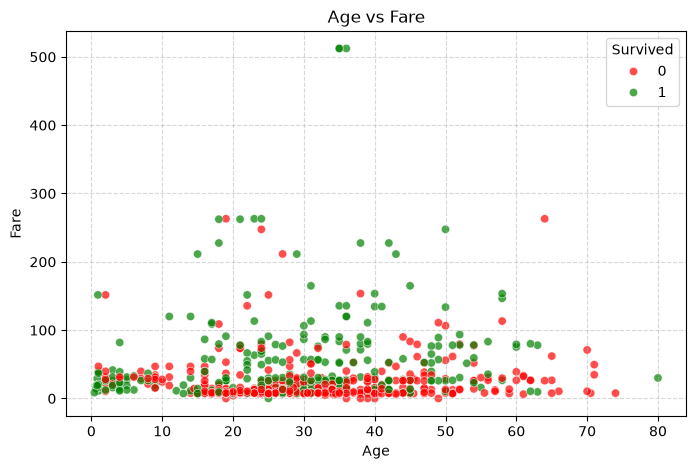

In [186]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="Age",y="Fare",hue="Survived",palette=["red","green"],alpha=0.7)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Observation

- There is no strong linear relationship between Age and Fare.
- Most passengers paid relatively low fares.
- Higher fares are mostly associated with first-class passengers.
- Survivors are more common among passengers who paid higher fares.

In [187]:
# Groupby on two columns
df.groupby(["Sex","Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

# Correlation Analysis

Correlation helps us understand the relationship between numerical features.

Values closer to:

- +1 indicate a strong positive relationship.
- -1 indicate a strong negative relationship.
- 0 indicate little or no relationship.

In [188]:
numerical_df = df.select_dtypes(include="number")

numerical_df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Figure size 800x600 with 0 Axes>

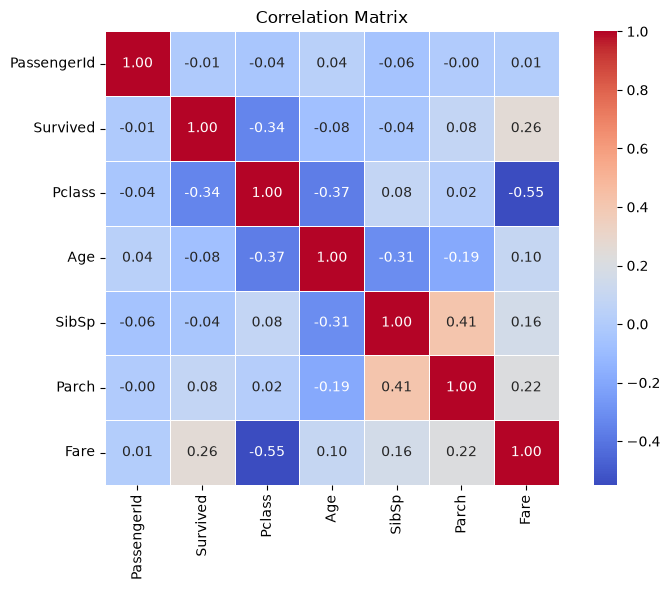

In [189]:
plt.figure(figsize=(8,6))

plt.figure(figsize=(8,6))

sns.heatmap(numerical_df.corr(),annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,square=True,cbar=True)
plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

### Observations

- Passenger class had a significant impact on survival, with first-class passengers showing the highest survival rate.
- Female passengers had a much higher survival rate than male passengers.
- Younger passengers showed relatively better survival chances compared to older passengers.
- Passengers who paid higher fares generally had higher survival rates.
- The embarkation port showed some variation in survival rates, although its impact was less significant than Sex and Passenger Class.

## Multivariate

In [190]:
df.pivot_table(index="Pclass", columns="Sex",values="Survived", aggfunc="mean")


Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


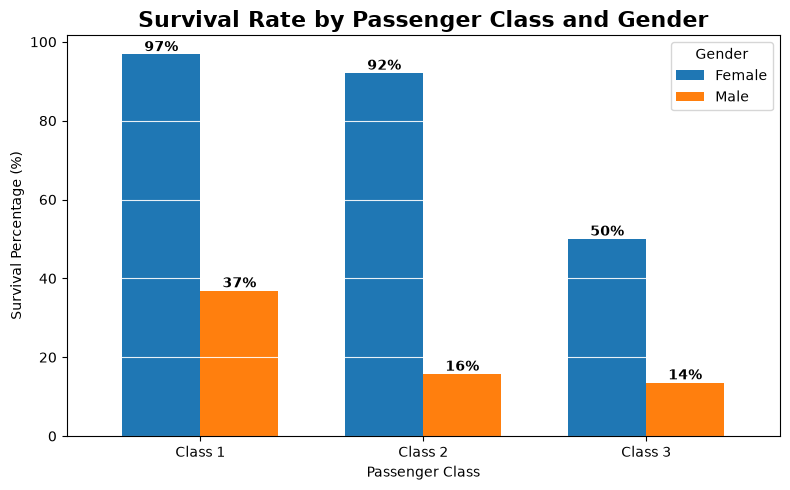

In [191]:
# Calculate survival percentage by Pclass and Sex
survival_rate = (pd.crosstab([df["Pclass"], df["Sex"]],df["Survived"],normalize="index") * 100)

# Keep only survival percentage (Survived = 1)
survival_rate = survival_rate[1].unstack()

# Rename columns
survival_rate.columns = ["Female", "Male"]

# Rename index
survival_rate.index = ["Class 1", "Class 2", "Class 3"]

# Plot
ax = survival_rate.plot(kind="bar",figsize=(8,5),width=0.7)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", fontsize=10, fontweight="bold")

plt.title("Survival Rate by Passenger Class and Gender", fontsize=16, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.grid(axis="y", linestyle="-", alpha=0.9, color = 'White')

plt.tight_layout()
plt.show()

# 5. Feature Engineering

Machine learning models cannot work directly with raw data.

Feature Engineering is the process of creating new features from existing data to improve model performance.

In the Titanic dataset, we create a new feature called **FamilySize** by combining:
- SibSp (Siblings/Spouses)
- Parch (Parents/Children)
- +1 (the passenger themselves)

This feature helps us analyze whether traveling alone or with family affected survival.

In [192]:
# Create FamilySize feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Display first few rows
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [193]:
# Analyze Survival Rate
df.groupby("FamilySize")["Survived"].mean().round(2)

FamilySize
1     0.30
2     0.55
3     0.58
4     0.72
5     0.20
6     0.14
7     0.33
8     0.00
11    0.00
Name: Survived, dtype: float64

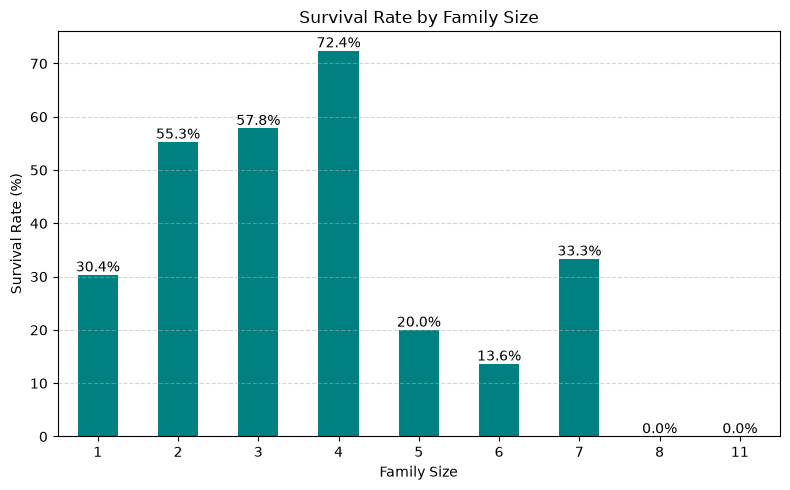

In [194]:
family_survival = df.groupby("FamilySize")["Survived"].mean() * 100

plt.figure(figsize=(8,5))

ax = family_survival.plot(kind="bar",color="teal")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observation

- Passengers traveling alone or with small families generally had higher survival rates.
- Very large families had lower survival rates.
- FamilySize provides additional information beyond SibSp and Parch individually.
- Therefore, FamilySize is a useful engineered feature for predicting survival.

## Create IsAlone Feature

A passenger is considered alone if the FamilySize equals 1.

This converts FamilySize into a simple binary feature.

In [195]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df.groupby("IsAlone")["Survived"].mean()


IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

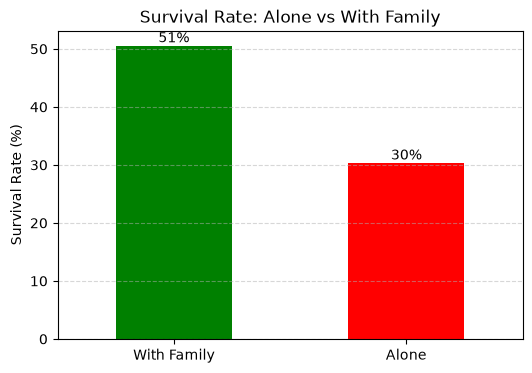

In [196]:
alone = df.groupby("IsAlone")["Survived"].mean()*100

alone.index = ["With Family","Alone"]

ax = alone.plot(kind="bar",figsize=(6,4),color=["green","red"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%")

plt.title("Survival Rate: Alone vs With Family")
plt.xlabel("")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

- Passengers traveling with family had a higher survival rate.
- Passengers traveling alone were less likely to survive.
- IsAlone is a useful binary feature for prediction.

## Extract Title from Name

Passenger names contain titles such as Mr, Mrs, Miss, and Master.

These titles provide useful information about gender, age group, and social status, making them valuable features for prediction.

In [197]:
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")

df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [198]:
# Survival by Title

title_survival = df.groupby("Title")["Survived"].mean().sort_values(ascending=False)*100

title_survival.head(10)

Title
Lady            100.00000
Ms              100.00000
Sir             100.00000
Mme             100.00000
the Countess    100.00000
Mlle            100.00000
Mrs              79.20000
Miss             69.78022
Master           57.50000
Major            50.00000
Name: Survived, dtype: float64

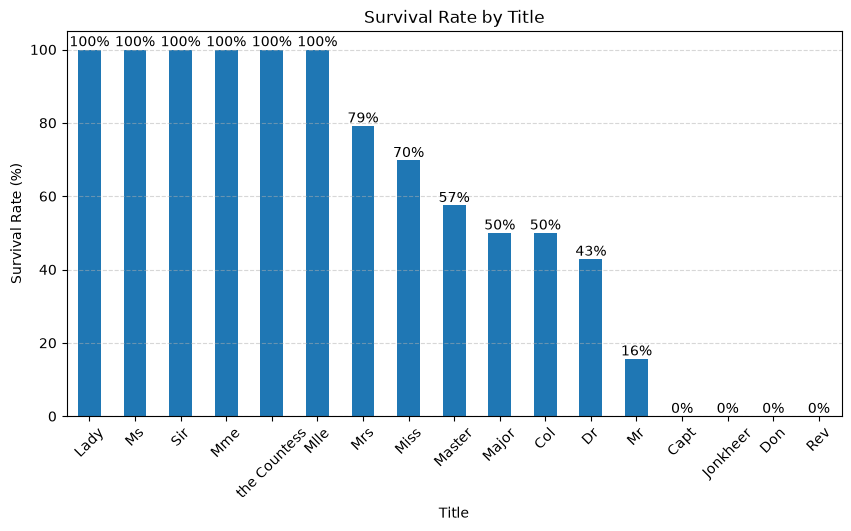

In [199]:
plt.figure(figsize=(10,5))

ax = title_survival.plot(kind="bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%")

plt.title("Survival Rate by Title")
plt.xlabel("Title")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

- Female titles such as **Mrs** and **Miss** had the highest survival rates.
- **Master** also showed a relatively high survival rate.
- **Mr** had the lowest survival rate among the common titles.
- Extracting Title from Name creates a more informative feature than using the full Name column.

## Create Age Groups

Continuous numerical features can be grouped into categories to simplify analysis.

Age is divided into meaningful groups using bins.

In [200]:
# First handle age missing values by filling them with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Then create AgeGroup
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

df.groupby("AgeGroup")["Survived"].mean().round(2)

AgeGroup
Child          0.58
Teen           0.43
Young Adult    0.35
Adult          0.40
Senior         0.23
Name: Survived, dtype: float64

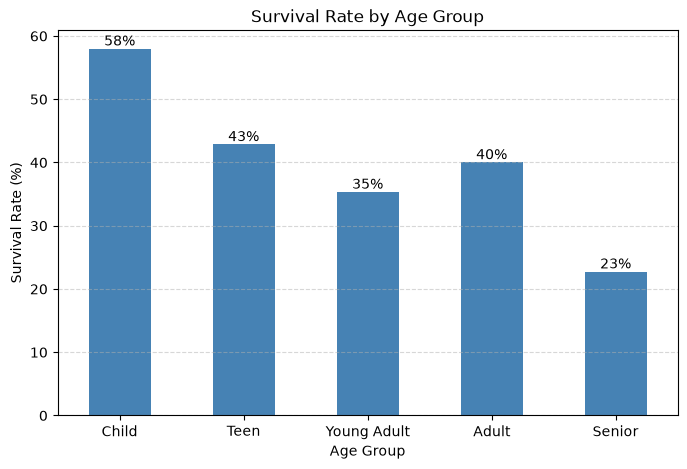

In [201]:
age_group = df.groupby("AgeGroup")["Survived"].mean()*100

ax = age_group.plot(kind="bar",figsize=(8,5),color="steelblue")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

- Children had the highest survival rate.
- Young adults and adults showed moderate survival rates.
- Senior passengers had the lowest survival rate.
- Age grouping helps reveal survival patterns more clearly than raw age values.

# 6. Data Preprocessing

In [202]:
# Check Missing Values Again
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
IsAlone          0
Title            0
AgeGroup         0
dtype: int64

### Observation

The dataset contains missing values in:

- Age
- Cabin
- Embarked

These missing values must be handled before training the machine learning model.

### Handle Missing Values

In [203]:
# Fill missing Age values using median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values using mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because most values are missing
df.drop("Cabin", axis=1, inplace=True)

### Handle Data Types

In [204]:
# df['Survived'] = df['Survived'].astype('category')

In [205]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
Title          0
AgeGroup       0
dtype: int64

### Observation

All missing values have been handled successfully.

- Age → Filled with median
- Embarked → Filled with mode
- Cabin → Dropped because of excessive missing values

### Drop Unnecessary Columns

Some columns do not contribute much to prediction.

In [206]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [207]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,2,0,Mr,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,2,0,Mrs,Adult
2,1,3,female,26.0,0,0,7.9250,S,1,1,Miss,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,2,0,Mrs,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,1,1,Mr,Young Adult


### Observation

The dataset now contains only useful features required for machine learning.

## Encode Categorical Features

Machine learning models only understand numbers.

We need to convert text values into numerical values.

In [208]:
df["Sex"] = df["Sex"].map({"male": 0,"female": 1})

In [209]:
df["Embarked"] = df["Embarked"].map({"S": 0,"C": 1,"Q": 2})

In [210]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,AgeGroup
0,0,3,0,22.0,1,0,7.2500,0,2,0,Mr,Young Adult
1,1,1,1,38.0,1,0,71.2833,1,2,0,Mrs,Adult
2,1,3,1,26.0,0,0,7.9250,0,1,1,Miss,Young Adult
3,1,1,1,35.0,1,0,53.1000,0,2,0,Mrs,Young Adult
4,0,3,0,35.0,0,0,8.0500,0,1,1,Mr,Young Adult


In [211]:
from sklearn.preprocessing import LabelEncoder
le_title = LabelEncoder()
le_agegroup = LabelEncoder()

df["Title"] = le_title.fit_transform(df["Title"])

df["AgeGroup"] = le_agegroup.fit_transform(df["AgeGroup"])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,AgeGroup
0,0,3,0,22.0,1,0,7.2500,0,2,0,11,4
1,1,1,1,38.0,1,0,71.2833,1,2,0,12,0
2,1,3,1,26.0,0,0,7.9250,0,1,1,8,4
3,1,1,1,35.0,1,0,53.1000,0,2,0,12,4
4,0,3,0,35.0,0,0,8.0500,0,1,1,11,4


In [212]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    int64  
 8   FamilySize  891 non-null    int64  
 9   IsAlone     891 non-null    int64  
 10  Title       891 non-null    int64  
 11  AgeGroup    891 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 83.7 KB


### Observation

Categorical variables have been converted into numerical values.

Sex:
- Male = 0
- Female = 1

Embarked:
- Southampton = 0
- Cherbourg = 1
- Queenstown = 2

### Check Data Types

In [213]:
df.dtypes

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
FamilySize      int64
IsAlone         int64
Title           int64
AgeGroup        int64
dtype: object

### Observation

All features are now numerical and ready for machine learning.

##  Final combined insight


In [214]:
print(df.pivot_table(index="Pclass", columns="Sex", values="Survived", aggfunc="mean"))

Sex            0         1
Pclass                    
1       0.368852  0.968085
2       0.157407  0.921053
3       0.135447  0.500000


# Final Insights

After performing Exploratory Data Analysis (EDA) on the Titanic dataset, several important patterns were discovered.

The analysis showed that survival was not random. Factors such as gender, passenger class, age, family size, and ticket fare had a significant influence on survival.

These insights provide a strong foundation for building a Machine Learning model to predict passenger survival.

### Key Insights

- Female passengers had a significantly higher survival rate than male passengers.
- First Class passengers were more likely to survive than those in Second and Third Class.
- Children had better survival chances compared to older passengers.
- Passengers traveling with small families had higher survival rates than those traveling alone or with very large families.
- Higher ticket fares were generally associated with better survival rates.
- Features such as **Sex**, **Pclass**, **Age**, **Fare**, and **FamilySize** appeared to be the most important predictors of survival.

In [215]:
# Save cleaned dataset
df.to_csv("../data/titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Conclusion

This project explored the Titanic dataset using Exploratory Data Analysis (EDA).

The analysis revealed that survival was strongly influenced by gender, passenger class, age, and family size. These findings helped identify the most informative features for prediction.

The cleaned dataset is now ready for Machine Learning model development, where these features can be used to predict passenger survival with improved accuracy.

# Next Step

After completing EDA, the next phase is Machine Learning.

The cleaned dataset can be used to:

- Perform feature encoding and scaling.
- Split the data into training and testing sets.
- Train multiple Machine Learning models.
- Evaluate model performance.
- Save the best model.
- Deploy the final model as a web application using Streamlit or Hugging Face.

# 7. Train-Test Split

The cleaned dataset is divided into training and testing sets before building Machine Learning models.

- Training Set (80%) is used to train the models.
- Testing Set (20%) is used to evaluate model performance.
- Stratified sampling is used to maintain the class distribution in both sets.

In [216]:
from sklearn.model_selection import train_test_split

# Features and Target
x = df.drop("Survived", axis=1)
y = df["Survived"]

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

print("Training Features :", x_train.shape)
print("Testing Features  :", x_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (712, 11)
Testing Features  : (179, 11)
Training Labels   : (712,)
Testing Labels    : (179,)


### Observation

The dataset has been successfully divided into training and testing sets.

- Training data contains 80% of the records.
- Testing data contains 20% of the records.
- Stratified sampling preserves the class distribution in both datasets.

# 8. Feature Scaling

Some Machine Learning algorithms perform better when numerical features are on a similar scale.

In this project, only continuous numerical features (**Age** and **Fare**) are standardized using StandardScaler.

Categorical and encoded features are not scaled.

In [217]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Numerical columns
numerical_columns = ["Age", "Fare"]

# Fit on training data
x_train[numerical_columns] = scaler.fit_transform(x_train[numerical_columns])

# Transform testing data
x_test[numerical_columns] = scaler.transform(x_test[numerical_columns])

x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,AgeGroup
692,3,0,-0.112078,0,0,0.513812,0,1,1,11,4
481,2,0,-0.112078,0,0,-0.662563,0,1,1,11,4
527,1,0,-0.112078,0,0,3.955399,0,1,1,11,4
855,3,1,-0.879807,0,1,-0.467874,0,2,0,12,3
801,2,1,0.118241,1,1,-0.115977,0,3,0,12,4


### Observation

Only the numerical features (**Age** and **Fare**) have been standardized.

The scaler was fitted only on the training data to avoid data leakage.

# 9. Model Training

## Model 1 — Logistic Regression

Logistic Regression is one of the most popular classification algorithms.

It estimates the probability of a passenger surviving by learning the relationship between the input features and the target variable.

This model is simple, fast, and works well as a baseline classifier.

In [218]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_auc_score)

# Create model
log_model = LogisticRegression(random_state=42)

# Train
log_model.fit(x_train, y_train)

# Prediction
log_pred = log_model.predict(x_test)

# Accuracy
log_acc = accuracy_score(y_test, log_pred)

print("Accuracy:", round(log_acc,4))

Accuracy: 0.8101


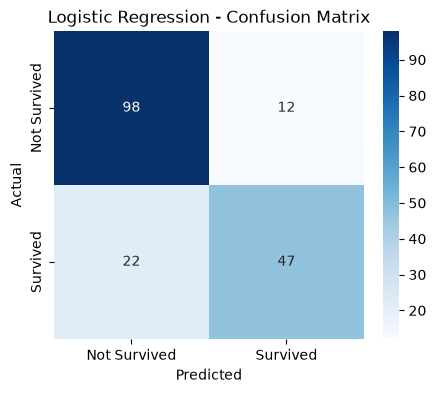

In [219]:
# Confusion Matrix
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Not Survived","Survived"],yticklabels=["Not Survived","Survived"])

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [220]:
# Classification Report
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [221]:
# ROC-AUC Score
log_prob = log_model.predict_proba(x_test)[:,1]

log_auc = roc_auc_score(y_test, log_prob)

print("ROC-AUC Score:", round(log_auc,4))

ROC-AUC Score: 0.8491


### Observation

- Logistic Regression successfully classified passengers into survived and non-survived classes.
- It provides a strong baseline model for comparison.
- The ROC-AUC score measures how well the model distinguishes between the two classes.

## Model 2 — Decision Tree

Decision Tree is a tree-based classification algorithm.

It splits the dataset into different branches based on feature values until a prediction is made.

Decision Trees are easy to understand and can capture non-linear relationships.

In [222]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(x_train, y_train)

# Prediction
dt_pred = dt_model.predict(x_test)

# Accuracy
dt_acc = accuracy_score(y_test, dt_pred)

print("Accuracy:", round(dt_acc,4))

Accuracy: 0.7989


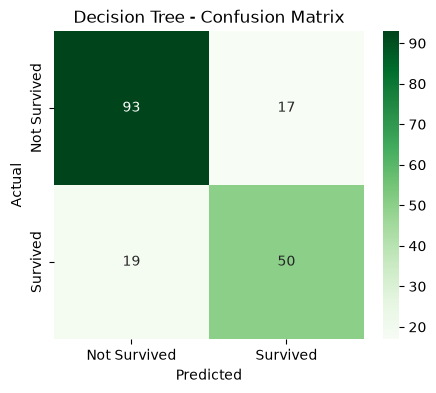

In [227]:
# Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=["Not Survived","Survived"],yticklabels=["Not Survived","Survived"])

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [228]:
# Classification Report
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.75      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [229]:
# ROC-AUC Score
dt_prob = dt_model.predict_proba(x_test)[:,1]

dt_auc = roc_auc_score(y_test, dt_prob)

print("ROC-AUC Score:", round(dt_auc,4))

ROC-AUC Score: 0.7814


### Observation

- Decision Tree successfully classified the passengers into survived and non-survived classes.
- It can capture complex decision boundaries but may overfit the training data.
- Its performance will be compared with other machine learning models.

## Model 3 -  Random Forest Classifier

Random Forest is an ensemble learning algorithm.

Instead of training only one Decision Tree, it trains many Decision Trees and combines their predictions.

It usually provides better accuracy and reduces overfitting compared to a single Decision Tree.

In [230]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [231]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8156424581005587


In [232]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       110
           1       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [233]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[95 15]
 [18 51]]


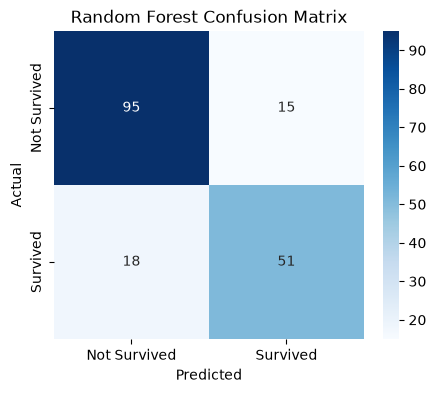

In [234]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Not Survived","Survived"],yticklabels=["Not Survived","Survived"])

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model 4 - Support Vector Machine (SVM)

Support Vector Machine (SVM) is a powerful supervised machine learning algorithm used for both classification and regression tasks.

It works by finding the optimal hyperplane that best separates different classes while maximizing the margin between them.

SVM performs well on high-dimensional datasets and is effective for binary classification problems.

In [235]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm = SVC(kernel="rbf",C=1.0,gamma="scale",random_state=42)

svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)

In [236]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8156424581005587


In [237]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [238]:
print(confusion_matrix(y_test, y_pred_svm))

[[96 14]
 [19 50]]


### Observation

- The Support Vector Machine (SVM) model was successfully trained on the Titanic dataset.
- It classified passengers into Survived and Not Survived categories.
- The accuracy indicates how well the model performed on unseen test data.
- Precision, Recall, and F1-score provide a detailed evaluation of the model's performance.
- The confusion matrix shows the number of correct and incorrect predictions for each class.

In [239]:
import sklearn
import numpy

print("Scikit-learn:", sklearn.__version__)
print("NumPy:", numpy.__version__)

Scikit-learn: 1.9.0
NumPy: 2.1.0


## Model 5 - KNN Model

In [240]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)

In [241]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7821229050279329


In [242]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       110
           1       0.75      0.65      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



In [243]:
print(confusion_matrix(y_test, y_pred_knn))

[[95 15]
 [24 45]]


## Model 6 - Naive Bayes

Naive Bayes is a supervised machine learning algorithm based on Bayes' Theorem.

It assumes that all input features are independent of each other, which makes it simple and fast.

Naive Bayes performs well on many classification problems and is commonly used for binary classification tasks.

In [244]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb = GaussianNB()

nb.fit(x_train, y_train)

y_pred_nb = nb.predict(x_test)

In [245]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.7821229050279329


In [246]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       110
           1       0.71      0.74      0.72        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [247]:
print(confusion_matrix(y_test, y_pred_nb))

[[89 21]
 [18 51]]


### Observation

- The Naive Bayes model was successfully trained on the Titanic dataset.
- It classified passengers into Survived and Not Survived categories.
- The model is computationally efficient and trains very quickly.
- The accuracy indicates the overall prediction performance on the test dataset.
- Precision, Recall, F1-score, and the confusion matrix provide a detailed evaluation of the model.

## Model 7 - XGBoost Classifier

In [265]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [289]:
# XGBoost Classifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
# Training
xgb_model.fit(x_train,y_train)

# Prediction
y_pred_xgb = xgb_model.predict(x_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test,y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

print(classification_report(y_test,y_pred_xgb))

XGBoost Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



# 10. Model Comparison

After training multiple machine learning models, their performance is compared using accuracy scores.

The model with the highest accuracy will be selected as the best-performing model for this project.

In [297]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","Support Vector Machine","K-Nearest Neighbors","Naive Bayes","XGBoost"],
    "Accuracy": [log_acc,dt_acc,rf_accuracy,svm_accuracy,knn_accuracy,nb_accuracy, xgb_accuracy]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
6,XGBoost,0.821229
3,Support Vector Machine,0.815642
2,Random Forest,0.815642
0,Logistic Regression,0.810056
1,Decision Tree,0.798883
4,K-Nearest Neighbors,0.782123
5,Naive Bayes,0.782123


### Observation

The performance comparison table shows the accuracy of all trained machine learning models on the Titanic Survival Prediction dataset.

Among all evaluated models, **XGBoost Classifier achieved the highest accuracy**, making it the best-performing model for this classification problem.

The results show that ensemble learning methods such as **XGBoost and Random Forest** performed better compared to individual algorithms due to their ability to capture complex patterns in the data.

Therefore, **XGBoost Classifier was selected as the final model for deployment.**

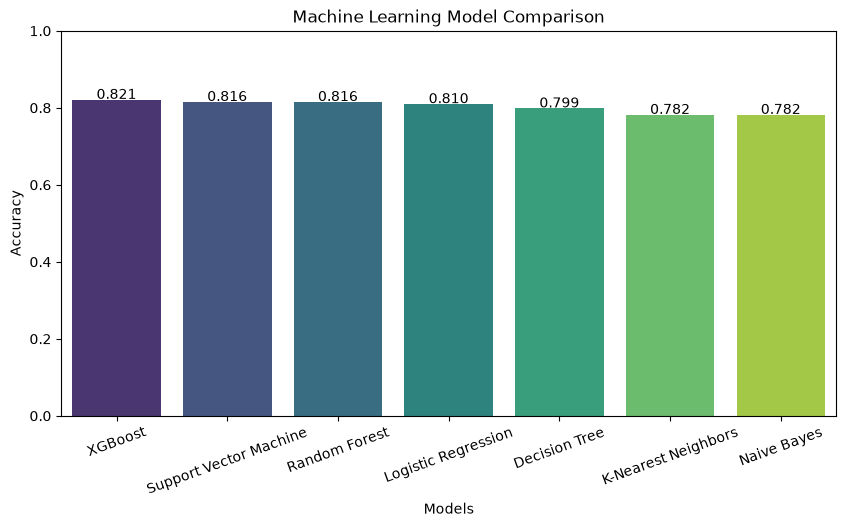

In [305]:
plt.figure(figsize=(10,5))

sns.barplot(data=results,x="Model",y="Accuracy",hue="Model",palette="viridis",legend=False)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

for i, v in enumerate(results["Accuracy"]):
    plt.text(i,v + 0.002,f"{v:.3f}",ha="center",fontsize=10)

plt.ylim(0,1)

plt.show()

### Model Comparison Visualization

The bar chart illustrates the accuracy comparison of all trained machine learning models.

XGBoost Classifier achieved the highest accuracy among all evaluated models, followed by Random Forest and Support Vector Machine.

# 11. Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best combination of model parameters to improve prediction performance.

In this project, GridSearchCV is used to optimize the Random Forest classifier.

In [306]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1)

grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [307]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Accuracy:
0.8259036737909977


In [308]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(x_test)

best_accuracy = accuracy_score(y_test, y_pred_best)

print("Tuned Random Forest Accuracy:", best_accuracy)

Tuned Random Forest Accuracy: 0.8044692737430168


### Observation

GridSearchCV was used to optimize the Random Forest Classifier by testing different combinations of hyperparameters using 5-fold cross-validation.

The best parameter combination was selected based on cross-validation accuracy. Although the tuned model performed well, XGBoost achieved the highest overall test accuracy and was selected as the final deployment model.

## Hyperparameter Tuning (XGBoost)

Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation.

The tuning process evaluated different combinations of:
- Number of estimators
- Maximum tree depth
- Learning rate

The best-performing XGBoost model was selected based on cross-validation accuracy and evaluated on the test dataset.

In [313]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}

Best Cross Validation Accuracy:
0.8216881709839455


In [318]:
from sklearn.metrics import accuracy_score, classification_report

best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(x_test)

xgb_tuned_accuracy = accuracy_score(y_test, y_pred)

print("Tuned XGBoost Accuracy:", xgb_tuned_accuracy)

print(classification_report(y_test, y_pred))

Tuned XGBoost Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



### Observation

Hyperparameter tuning was performed using GridSearchCV to optimize the XGBoost Classifier.

Although the tuned model achieved a cross-validation accuracy of **82.17%**, its test accuracy (**81.56%**) was slightly lower than the default XGBoost model (**82.12%**).

Therefore, the default XGBoost model was selected as the final model for deployment because it provided the best performance on the unseen test dataset.

# 12. Save the Best Model

After selecting the best-performing model, it is saved using the Joblib library.

Saving the trained model allows it to be reused later without retraining, making deployment faster and more efficient.

In [331]:
import joblib

# Save best model
joblib.dump(xgb_model, "../models/model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [332]:
joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [333]:
# Verify saved model
import os

print(os.listdir("../models"))

['model.pkl', 'scaler.pkl']


### Observation

- The best-performing **XGBoost Classifier** has been successfully saved as the final machine learning model.
- The fitted **StandardScaler** has also been saved for preprocessing numerical features.
- Both the model and scaler will be loaded directly into the Streamlit application to make predictions without retraining.
- Saving the trained artifacts ensures consistent preprocessing and prediction during deployment.

# 13. Streamlit Web Application

The trained model is deployed using Streamlit.

The web application allows users to enter passenger details and predicts whether the passenger would survive or not.

- app.py file


In [343]:
import joblib

loaded_model = joblib.load("../models/model.pkl")

print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>
